<h1 align="center" style="color:#ff4b5c;">🧬 Breast Cancer Detection using Machine Learning</h1>

<p align="center">
<b>Author:</b> Varun Kumar<br>
<b>Project Type:</b> Medical AI / Classification <br>
<b>Goal:</b> Predict whether a tumor is <span style="color:#e63946;"><b>Malignant</b></span> or 
<span style="color:#2a9d8f;"><b>Benign</b></span>
</p>


## 🎯 Project Objective
<div style="background-color:#f1f8ff;padding:15px;border-radius:10px;border-left:6px solid #1f77b4;">

The objective of this project is to build a **Machine Learning model** that can analyze medical data and predict whether a tumor is **benign or malignant**.  

This system helps in:
- Early detection of breast cancer  
- Assisting doctors with data-driven predictions  
- Improving diagnostic accuracy using AI  

</div>

In [1]:
import os
import numpy as np 
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
dataset_path = r'Mammography -Cancer-Detection-Dataset/train'

categories = ["benign", "malignant"]

img_size = 224

data = []
labels = []

In [3]:
for category in categories:
    
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (img_size, img_size))
            data.append(image)
            labels.append(label)
        except:
            pass

In [4]:
X = np.array(data)
y = np.array(labels)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (2372, 224, 224, 3)
Labels shape: (2372,)


In [5]:
X = X/255.0

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

datagen.fit(X)

In [9]:
test_dataset_path = r'Mammography -Cancer-Detection-Dataset/test'

test_data = []
test_labels = []

for category in categories:
    
    path = os.path.join(test_dataset_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        test_img_path = os.path.join(path, img)

        try:
            test_image = cv2.imread(test_img_path)
            test_image = cv2.resize(image, (img_size, img_size))
            test_data.append(image)
            test_labels.append(label)
        except:
            pass
X_test = np.array(test_data)
y_test = np.array(test_labels)

print("Dataset shape:", X_test.shape)
print("Labels shape:", y_test.shape)

X = X/255.0

Dataset shape: (336, 224, 224, 3)
Labels shape: (336,)


In [11]:
history = model.fit(
    datagen.flow(X, y, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20
)

C:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 49s 605ms/step - accuracy: 0.6598 - loss: 0.6536 - val_accuracy: 0.6190 - val_loss: 173.2941
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 581ms/step - accuracy: 0.6615 - loss: 0.6493 - val_accuracy: 0.6190 - val_loss: 222.1773
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 692ms/step - accuracy: 0.6615 - loss: 0.6478 - val_accuracy: 0.6190 - val_loss: 228.7959
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 599ms/step - accuracy: 0.6615 - loss: 0.6487 - val_accuracy: 0.6190 - val_loss: 193.1259
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 55s 734ms/step - accuracy: 0.6615 - loss: 0.6455 - val_accuracy: 0.6190 - val_loss: 166.2615
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 49s 650ms/step - accuracy: 0.6615 - loss: 0.6481 - val_accuracy: 0.6190 - val_loss: 189.8199
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 668ms/step - accuracy: 0.6615 - loss: 0.6448 - val_accuracy: 0.6190 - val_loss: 150.9879
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 51s 686ms/step - accuracy: 0.6615 - loss: 0.6

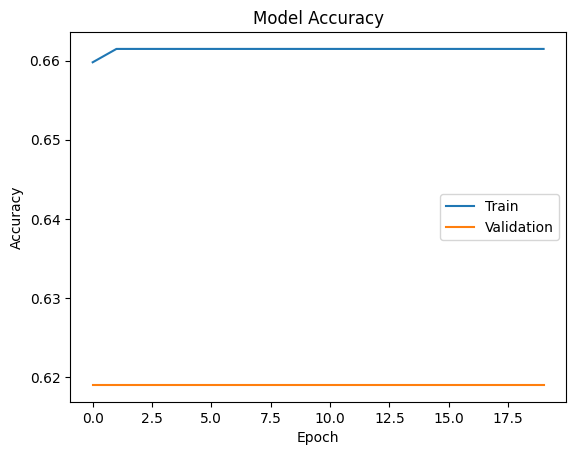

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

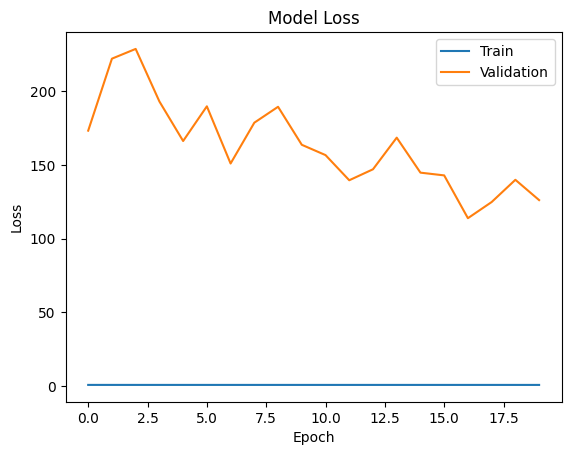

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.6190 - loss: 126.1410  
Test Accuracy: 0.6190476417541504


In [15]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

print(cm)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step
[[208   0]
 [128   0]]


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      1.00      0.76       208
           1       0.00      0.00      0.00       128

    accuracy                           0.62       336
   macro avg       0.31      0.50      0.38       336
weighted avg       0.38      0.62      0.47       336



C:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [17]:
def predict_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.reshape(img, (1,224,224,3))

    prediction = model.predict(img)

    if prediction > 0.5:
        print("Malignant (Cancer Detected)")
    else:
        print("Benign (No Cancer)")

In [19]:
predict_image(r"Mammography -Cancer-Detection-Dataset/valid/benign/25_1962456803_png.rf.af7491ff94fcd2f6c0ee5e59e3e84428.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Benign (No Cancer)


In [18]:
model.save("breast_cancer_cnn_model.h5")